In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import os
import joblib

**Load processed data**

In [2]:
DATA_DIR = Path.cwd().parent / 'data' / 'processed'
train_split = pd.read_csv(DATA_DIR / 'train_split.csv')
val_split = pd.read_csv(DATA_DIR / 'val_split.csv')

feature_cols = [c for c in train_split.columns if 'sensor' in c]
print(f"Using {len(feature_cols)} features")

Using 49 features


**Regression Model**

In [3]:
X_train = train_split[feature_cols]
y_train = train_split['RUL']
X_val = val_split[feature_cols]
y_val = val_split['RUL']

reg_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
reg_model.fit(X_train, y_train)

preds = reg_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)
print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE: {mae:.2f} cycles")

RMSE: 34.38 cycles
MAE: 24.70 cycles


In [4]:
xgb_val_preds = pd.DataFrame({
    'unit': val_split['unit'],
    'cycle': val_split['cycle'],
    'xgb_pred': reg_model.predict(val_split[feature_cols])
})
xgb_val_preds.to_csv('../data/processed/xgb_val_predictions.csv', index=False)
print(xgb_val_preds.shape)

(4070, 3)


In [5]:
threshold = 30
train_split['fail_within_30'] = (train_split['RUL'] <= threshold).astype(int)
val_split['fail_within_30'] = (val_split['RUL'] <= threshold).astype(int)

**Classification**

In [6]:
y_train_clf = train_split['fail_within_30']
y_val_clf = val_split['fail_within_30']

clf_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
clf_model.fit(X_train, y_train_clf)

clf_preds = clf_model.predict(X_val)
clf_probs = clf_model.predict_proba(X_val)[:, 1]  # probability of class 1 (failing soon)

print(f"Precision: {precision_score(y_val_clf, clf_preds):.3f}")
print(f"Recall: {recall_score(y_val_clf, clf_preds):.3f}")
print(f"F1: {f1_score(y_val_clf, clf_preds):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val_clf, clf_probs):.3f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_val_clf, clf_preds))

Precision: 0.903
Recall: 0.858
F1: 0.880
ROC-AUC: 0.991

Confusion matrix:
[[3393   57]
 [  88  532]]


In [7]:
threshold = 0.3  # more sensitive to catching potential failures
clf_preds_adjusted = (clf_probs >= threshold).astype(int)

print(f"At threshold={threshold}:")
print(f"Precision: {precision_score(y_val_clf, clf_preds_adjusted):.3f}")
print(f"Recall: {recall_score(y_val_clf, clf_preds_adjusted):.3f}")

At threshold=0.3:
Precision: 0.805
Recall: 0.916


Lowered the classification threshold from 0.5 to 0.3 to prioritize recall over precision, reflecting that missing a genuine failure (false negative) carries a much higher real-world cost than an unnecessary inspection (false positive).

**Feature importance**

sensor_4_rollmean     0.235010
sensor_11_rollmean    0.163113
sensor_15_rollmean    0.143961
sensor_21_rollmean    0.107354
sensor_9_rollmean     0.052386
sensor_20_rollmean    0.033504
sensor_2_rollmean     0.023732
sensor_14_rollmean    0.017674
sensor_3_rollmean     0.017015
sensor_7_rollmean     0.016038
dtype: float32


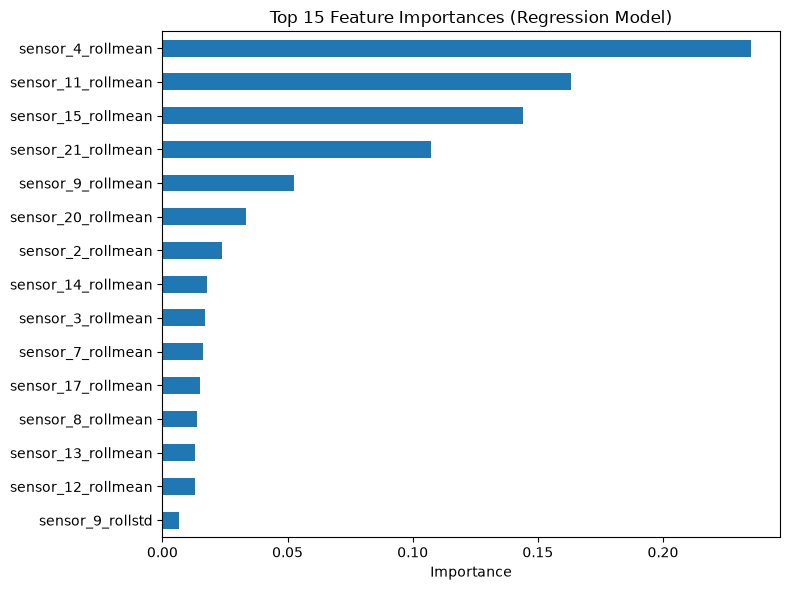

In [8]:
importances = pd.Series(reg_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(10))

importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Regression Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**Save model**

In [9]:
os.makedirs('../models', exist_ok=True)

reg_model.save_model('../models/xgb_regressor.json')
clf_model.save_model('../models/xgb_classifier.json')

scaler = joblib.load('../models/scaler.joblib')  # loading fitted scaler